Found 4 images. Running detection...

Processing: 9d33d1df-b877-4328-baa4-0f469259eed3.jpeg
Results saved to C:\Users\KRISHNENDU\PyNotebookTutorials\Image analysis DL\runs\detect\predict12

Detected Objects:


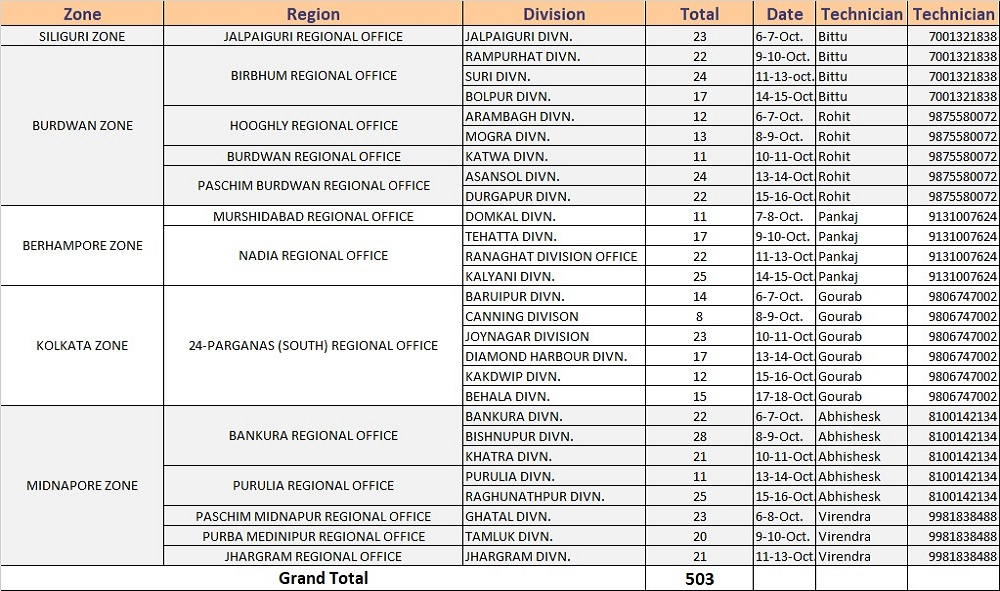


-----------------------------------------------

Processing: deecd2a4-8110-42a2-9a8a-be81387547d2.jpeg
Results saved to C:\Users\KRISHNENDU\PyNotebookTutorials\Image analysis DL\runs\detect\predict12

Detected Objects:


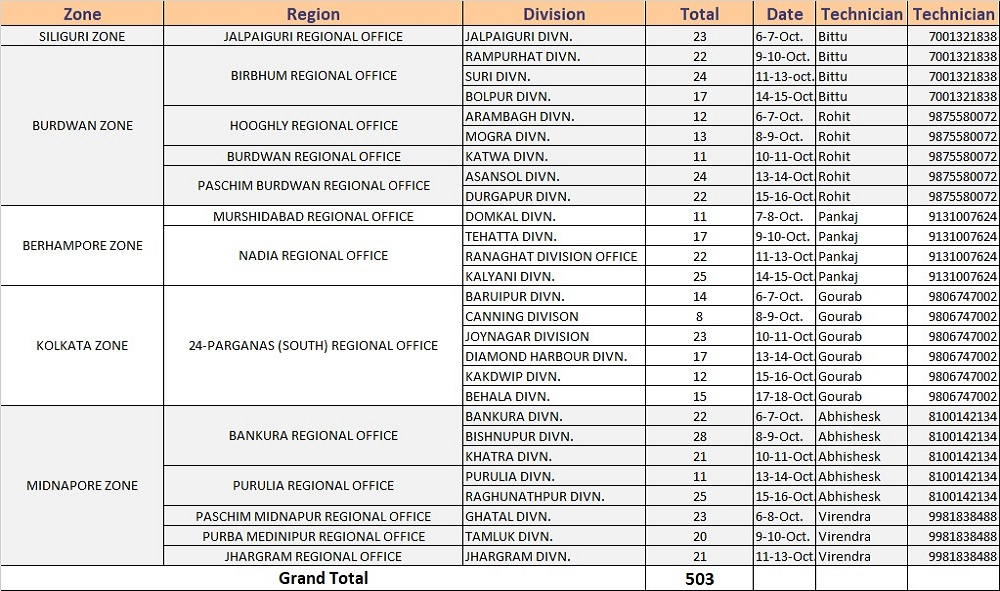


-----------------------------------------------

Processing: istockphoto-538686713-612x612.jpg
Results saved to C:\Users\KRISHNENDU\PyNotebookTutorials\Image analysis DL\runs\detect\predict12

Detected Objects:


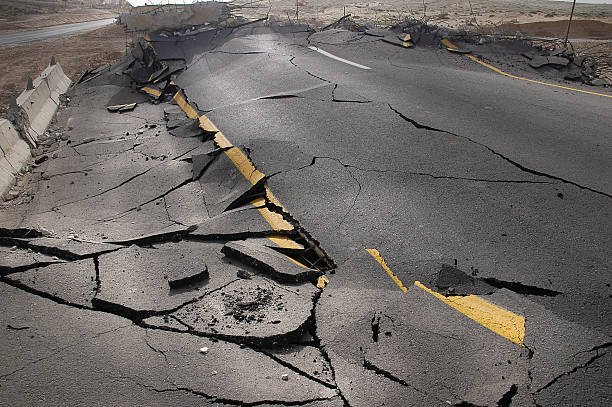


-----------------------------------------------

Processing: potholes-on-bad-asphalt-road-600nw-2476800079.png
Results saved to C:\Users\KRISHNENDU\PyNotebookTutorials\Image analysis DL\runs\detect\predict12

Detected Objects:


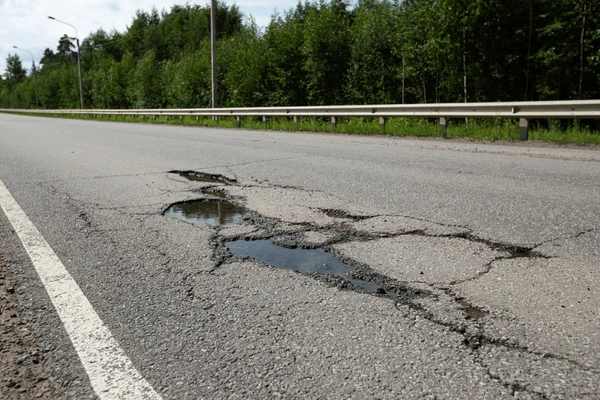


-----------------------------------------------

✅ All images processed successfully!


In [3]:
# Step 1: Import necessary libraries
from ultralytics import YOLO
import cv2
import os
from PIL import Image
from IPython.display import display

# Step 2: Load the YOLO model
model = YOLO('yolov8n.pt')  # You can switch to yolov8s.pt or yolov8m.pt for higher accuracy

# Step 3: Define the folder containing your images
image_folder = r"E:\Web Development\Final year project\myprojectbackend\myuploads"

# Step 4: Define allowed image extensions
valid_extensions = ('.jpg', '.jpeg', '.png', '.jfif', '.bmp', '.webp')

# Step 5: Get all image file paths
image_files = [
    os.path.join(image_folder, f)
    for f in os.listdir(image_folder)
    if f.lower().endswith(valid_extensions)
]

if not image_files:
    print("⚠️ No image files found in the folder!")
else:
    print(f"Found {len(image_files)} images. Running detection...\n")

# Step 6: Run inference on all images
for image_path in image_files:
    print(f"Processing: {os.path.basename(image_path)}")

    # Run YOLO inference
    results = model.predict(source=image_path, conf=0.25, iou=0.7, save=True, verbose=False)

    # Process each result
    for r in results:
        names = r.names
        print("\nDetected Objects:")
        for box in r.boxes:
            coords = box.xyxy[0].tolist()
            class_id = box.cls[0].item()
            conf = box.conf[0].item()
            class_name = names[int(class_id)]
            print(f" - {class_name} (Confidence: {conf:.2f}) at [{int(coords[0])}, {int(coords[1])}, {int(coords[2])}, {int(coords[3])}]")

        # Display the result image inline (in Jupyter)
        try:
            # Render bounding boxes directly from results
            img_with_boxes = r.plot()  # BGR format
            img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)
            display(Image.fromarray(img_rgb))
        except Exception as e:
            print(f"❌ Could not display image: {e}")

    print("\n-----------------------------------------------\n")

print("✅ All images processed successfully!")
